# Clustering Parameter Sweep

In [1]:
REPO_NAME = "ssl-data-curation"

In [2]:
import os, sys, subprocess, random, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from transformers import AutoImageProcessor, AutoModel
from hdbscan import HDBSCAN

if not os.path.exists(REPO_NAME):
    subprocess.run(["git", "clone", "https://github.com/facebookresearch/ssl-data-curation.git"], check=True)
sys.path.insert(0, os.path.abspath(REPO_NAME))

from src.clusters import HierarchicalCluster
import src.hierarchical_kmeans_gpu as hkmg
import src.hierarchical_sampling as hs

print("ssl-data-curation ready.")

import other_clustering_methods as ocm

import matplotlib.pyplot as plt
import seaborn as sns
import umap
import optuna
import ast

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


ssl-data-curation ready.


In [3]:
_PLACES_365_WEIGHTS_URL = (
    "http://places2.csail.mit.edu/models_places365/{model_id}_places365.pth.tar"
)

In [4]:
os.path.abspath("")

'c:\\Users\\Kacper\\Documents\\iad 6 sem\\wb2\\WB2_Project'

In [20]:
PROJECT_PATH = Path("")
BASE = Path(r"data\places365_10_classes\129")

# IMAGENET_TRAIN_DIR = "/home/sirko/wb-data/train"
REPO_NAME = "ssl-data-curation"
DATASET = "places365_alpha1"   # "places365_alpha1|2|3",
OPTUNA_TIMEOUT = 3600 # sekund per metoda
DATASET_PATH_DICT = {
    "places365_alpha05": BASE/ "alpha_05/train",
    "places365_alpha1":  BASE/ "alpha_1/train",
    "places365_alpha2":  BASE/ "alpha_2/train",
}
DATASET_PATH = DATASET_PATH_DICT[DATASET]
# CLUSTERING_METHOD = "dbscan"  # "hierarchical" | "kmeans" | "dbscan"

SEED              = 42
EMBEDDINGS        = "dino"   # "resnet" | "dino"
DINO_MODEL        = "facebook/dinov2-large"
SAMPLING_METHODS =  ["agglomerative", "kmeans"] # "kmeans","dbscan","hierarchical","agglomerative, "hdbscan"

IF_LOAD_RESULTS = True
LOAD_DINO_EMBEDDINGS_FROM_PKL = True
DINO_EMBEDDINGS_PKL_PATH = os.path.join(PROJECT_PATH, "dino_embeddings1.0_places365.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [6]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)

##  Extract embeddings

In [7]:
import torch.nn.functional as F

class ResnetTransform:
    def __init__(self):
        self.transfrom = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    def __call__(self,img):
        return self.transfrom(img)

class DinoTransform:
    def __init__(self, processor=AutoImageProcessor.from_pretrained('facebook/dinov2-large')):
        self.processor = processor
    def __call__(self, img):
        return self.processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
    
TRANSFORM_DICT = {'dino':DinoTransform(), "resnet":ResnetTransform()}
TRANSFORM = TRANSFORM_DICT[EMBEDDINGS]

def _load_places_365_state_dict(model_id: str, device: torch.device) -> dict[str, torch.Tensor]:
    checkpoint = torch.hub.load_state_dict_from_url(
        _PLACES_365_WEIGHTS_URL.format(model_id=model_id),
        map_location=device,
    )
    state_dict = checkpoint["state_dict"]
    return {k.replace("module.", ""): v for k, v in state_dict.items()}

def get_resnet50_places365_embedings(dataset, batch_size=128):
    extractor = models.resnet50()
    state_dict = _load_places_365_state_dict("resnet50", device)
    extractor.fc = nn.Linear(extractor.fc.in_features, 365)
    extractor.load_state_dict(state_dict)
    extractor.fc = nn.Identity()  # usunięcie głowy do ekstrakcji cech
    extractor.eval().to(device)
    
    all_features = []
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        feature_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        for imgs, _ in tqdm(feature_loader, desc="Places365 Feature extraction"):
            feat = extractor(imgs.to(device))
            all_features.append(feat.cpu())            
    return torch.cat(all_features).to(device)

def get_dino_embedings(dataset, batch_size=128):
    extractor = AutoModel.from_pretrained('facebook/dinov2-large')
    extractor.eval()
    extractor.to(device)
    all_embedings = []
    with torch.inference_mode(), torch.amp.autocast('cuda'):
        extr_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        for imgs, labels in tqdm(extr_loader, desc="Dino Feature extraction"):
            imgs = imgs.to(device)
            outputs = extractor(imgs)
            embedings = outputs.last_hidden_state[:,0,:]
            all_embedings.append(embedings.cpu())
            
    return torch.cat(all_embedings).to(device)

EMBEDDINGS_EXTRACTOR_DICT ={'dino': get_dino_embedings, 'resnet':get_resnet50_places365_embedings}
EMBEDDINGS_EXTRACTOR = EMBEDDINGS_EXTRACTOR_DICT[EMBEDDINGS]

def load_dino_embeddings_from_pkl(pkl_path: str, device: torch.device) -> torch.Tensor:
    """Wczytuje wcześniej obliczone embeddingi DINO z pliku .pkl."""
    import pickle
    print(f"Wczytywanie embeddingów z: {pkl_path}")
    data = torch.load(pkl_path, map_location=device)
    # Obsługa zarówno samego tensora, jak i słownika {"embeddings": tensor}
    if isinstance(data, dict):
        tensor = data.get("embeddings", data.get("dino_embeddings", next(iter(data.values()))))
    else:
        tensor = data
    if not isinstance(tensor, torch.Tensor):
        tensor = torch.tensor(tensor)
    print(f"Wczytano embeddingi: shape={tuple(tensor.shape)}, dtype={tensor.dtype}")
    return tensor.float().to(device)


## Clustering backends


In [8]:
def _hierarchical_labels(cfg: dict, embeddings: torch.Tensor):
    clusters_dict = hkmg.hierarchical_kmeans_with_resampling(
        data=embeddings.to(device),
        n_clusters=cfg["n_clusters"],
        n_levels=len(cfg["n_clusters"]),
        sample_sizes=cfg["sample_sizes"],
        n_resamples=cfg.get("n_resamples", 10),
        verbose=False,
    )
    cl = HierarchicalCluster.from_dict(clusters_dict)
    n_levels = max(cl.clusters.keys())

    def resolve_to_data_indices(level, cluster_idx):
        if level == 1:
            return np.asarray(cl.clusters[1][cluster_idx])
        child_indices = cl.clusters[level][cluster_idx]
        return np.concatenate([resolve_to_data_indices(level - 1, c) for c in child_indices])

    labels = np.full(len(embeddings), -1, dtype=int)
    for coarse_id in range(len(cl.clusters[n_levels])):
        data_idx = resolve_to_data_indices(n_levels, coarse_id)
        labels[data_idx] = coarse_id

    if (labels == -1).any():
        labels[labels == -1] = labels.max() + 1

    return labels, cl


def _kmeans_labels(cfg: dict, embeddings_np: np.ndarray) -> np.ndarray:
    km = KMeans(n_clusters=cfg["n_clusters"], n_init=cfg.get("n_init", "auto"), random_state=SEED)
    return km.fit_predict(embeddings_np), None


def _dbscan_labels(cfg: dict, embeddings_np: np.ndarray) -> np.ndarray:
    db = DBSCAN(eps=cfg["eps"], min_samples=cfg["min_samples"], n_jobs=-1)
    labels = db.fit_predict(embeddings_np)
    return labels, None

def _agglomerative_labels(cfg, embeddings_np):
    agg = AgglomerativeClustering(n_clusters=cfg["n_clusters"], linkage=cfg.get("linkage", "ward"))
    return agg.fit_predict(embeddings_np), None

def _hdbscan_labels(cfg, embeddings_np):
    hdb = HDBSCAN(min_cluster_size=cfg["min_cluster_size"], min_samples=cfg.get("min_samples", 5), cluster_selection_method="leaf")
    return hdb.fit_predict(embeddings_np), None


def run_clustering(cfg: dict, embeddings: torch.Tensor, embeddings_np: np.ndarray):
    embeddings_norm = F.normalize(embeddings, p=2, dim=1)
    embeddings_np_norm = embeddings_norm.cpu().numpy()
    method = cfg["method"]
    if method == "hierarchical":
        return _hierarchical_labels(cfg, embeddings_norm)
    elif method == "kmeans":
        return _kmeans_labels(cfg, embeddings_np_norm)
    elif method == "dbscan":
        return _dbscan_labels(cfg, embeddings_np_norm)
    elif method == "agglomerative":
        return _agglomerative_labels(cfg, embeddings_np_norm)
    elif method == "hdbscan":
        return _hdbscan_labels(cfg, embeddings_np_norm)
    else:
        raise ValueError(f"Unknown method: {method}")

def cfg_from_trial(method, params):
    if method != "hierarchical":
        return {"method": method, **params}
    n_levels = params["n_levels"]
    if n_levels == 2:
        return {"method": "hierarchical",
                "n_clusters":   [params["fine_k"], params["coarse_k"]],
                "sample_sizes": [params["fine_ss"], params["coarse_ss"]],
                "n_resamples":  params["n_resamples"]}
    else:
        return {"method": "hierarchical",
                "n_clusters":   [params["fine_k"], params["mid_k"], params["coarse_k"]],
                "sample_sizes": [params["fine_ss"], params["mid_ss"], params["coarse_ss"]],
                "n_resamples":  params["n_resamples"]}
        


## Metric helpers

In [9]:
def kl_from_uniform(labels: np.ndarray) -> float:
    valid = labels[labels >= 0]
    k = int(labels.max()) + 1
    counts = np.bincount(valid, minlength=k).astype(float)
    counts = counts[counts > 0]   # ignore empty bins
    p = counts / counts.sum()
    k_eff = len(counts)
    uniform = np.ones(k_eff) / k_eff
    return float(scipy_entropy(p, uniform))


def db_score(embeddings_np: np.ndarray, labels: np.ndarray) -> float:
    valid_mask = labels >= 0
    if len(np.unique(labels[valid_mask])) < 2:
        return float("nan")
    return float(davies_bouldin_score(embeddings_np[valid_mask], labels[valid_mask]))


def noise_fraction(labels: np.ndarray) -> float:
    return float((labels == -1).sum() / len(labels))


In [24]:
skewed_ds = datasets.ImageFolder(DATASET_PATH, TRANSFORM)
NUM_CLASSES = len(skewed_ds.classes)    
if LOAD_DINO_EMBEDDINGS_FROM_PKL:
    embeddings = torch.load(DINO_EMBEDDINGS_PKL_PATH, map_location=device).float()
else:
    embeddings = EMBEDDINGS_EXTRACTOR(skewed_ds).float()
    torch.save(skewed_ds.cpu(), DINO_EMBEDDINGS_PKL_PATH)
    print(f"Zapisano embeddingi do: {DINO_EMBEDDINGS_PKL_PATH}")

embeddings_np = embeddings.cpu().numpy()
embeddings_norm = F.normalize(embeddings, p=2, dim=1)
embeddings_np_norm = embeddings_norm.cpu().numpy()

C:\Users\Kacper\AppData\Local\Temp\ipykernel_20744\1427673997.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load(DINO_EMBEDDINGS_PKL_PATH, map_locat

## Optuna Objectives

In [11]:
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective_kmeans(trial):
    n_clusters = trial.suggest_int("n_clusters", 20, 600)
    cfg = {"method": "kmeans", "n_clusters": n_clusters}
    set_seed(SEED)
    labels, _ = run_clustering(cfg, embeddings, embeddings_np)
    return kl_from_uniform(labels), db_score(embeddings_np_norm, labels)

def objective_dbscan(trial):
    eps = trial.suggest_float("eps", 0.8, 1.45)
    min_samples = trial.suggest_int("min_samples", 2, 25)
    cfg = {"method": "dbscan", "eps": eps, "min_samples": min_samples}
    set_seed(SEED)
    labels, _ = run_clustering(cfg, embeddings, embeddings_np)
    if noise_fraction(labels) > 0.5:
        raise optuna.TrialPruned()
    if len(np.unique(labels[labels >= 0])) < 2:
        raise optuna.TrialPruned()
    return kl_from_uniform(labels), db_score(embeddings_np_norm, labels)

def objective_hierarchical(trial):
    n_levels    = trial.suggest_int("n_levels", 2, 3)
    fine_k      = trial.suggest_int("fine_k", 50, 200)
    coarse_k    = trial.suggest_int("coarse_k", 5, 30)
    n_resamples = trial.suggest_int("n_resamples", 5, 25)
    fine_ss     = trial.suggest_int("fine_ss", 10, 100)
    coarse_ss   = trial.suggest_int("coarse_ss", 100, 1000)

    if n_levels == 2:
        n_clusters   = [fine_k, coarse_k]
        sample_sizes = [fine_ss, coarse_ss]
    else:
        mid_k  = trial.suggest_int("mid_k", coarse_k + 1, max(coarse_k + 2, fine_k - 1))
        mid_ss = trial.suggest_int("mid_ss", 50, 300)
        n_clusters   = [fine_k, mid_k, coarse_k]
        sample_sizes = [fine_ss, mid_ss, coarse_ss]

    cfg = {"method": "hierarchical", "n_clusters": n_clusters,
           "sample_sizes": sample_sizes, "n_resamples": n_resamples}
    set_seed(SEED)
    labels, _ = run_clustering(cfg, embeddings, embeddings_np)
    return kl_from_uniform(labels), db_score(embeddings_np_norm, labels)

def objective_agglomerative(trial):
    n_clusters = trial.suggest_int("n_clusters", 3, 200)
    linkage = trial.suggest_categorical("linkage", ["ward", "average", "complete", "single"])
    cfg = {"method": "agglomerative", "n_clusters": n_clusters, "linkage": linkage}
    set_seed(SEED)
    labels, _ = run_clustering(cfg, embeddings, embeddings_np)
    return kl_from_uniform(labels), db_score(embeddings_np_norm, labels)

def objective_hdbscan(trial):
    min_cluster_size = trial.suggest_int("min_cluster_size", 10, 2000)
    min_samples = trial.suggest_int("min_samples", 1, 50)
    cluster_selection_method = trial.suggest_categorical("cluster_selection_method", ["eom", "leaf"])
    cfg = {
        "method": "hdbscan",
        "min_cluster_size": min_cluster_size,
        "min_samples": min_samples,
    }
    set_seed(SEED)
    labels, _ = run_clustering(cfg, embeddings, embeddings_np)
    if noise_fraction(labels) > 0.5:
        raise optuna.TrialPruned()
    if len(np.unique(labels[labels >= 0])) < 2:
        raise optuna.TrialPruned()
    return kl_from_uniform(labels), db_score(embeddings_np_norm, labels)

ALL_OBJECTIVES = {
    "kmeans":        objective_kmeans,
    "dbscan":        objective_dbscan,
    "hierarchical":  objective_hierarchical,
    "agglomerative": objective_agglomerative,
    "hdbscan":       objective_hdbscan,
}

OBJECTIVES = {m: ALL_OBJECTIVES[m] for m in SAMPLING_METHODS}

## Run optuna

In [12]:
if IF_LOAD_RESULTS and (PROJECT_PATH /"optuna_results.csv").exists():
    df_ranked = pd.read_csv(Path(r"optuna_results.csv"))
    df_ranked = df_ranked[[m in SAMPLING_METHODS for m in df_ranked["method"]]]
    display(df_ranked[["method", "config", "kl_divergence", "davies_bouldin", "combined_score"]].head(15))
else:
    raise Exception("gsd")
    studies = {}
    for method, objective in OBJECTIVES.items():
        print(f"\n── Optuna: {method}")
        study = optuna.create_study(
            directions=["minimize", "minimize"],
            sampler=optuna.samplers.TPESampler(seed=SEED),
            study_name=method,
        )
        study.optimize(objective, timeout=OPTUNA_TIMEOUT, show_progress_bar=True, gc_after_trial=True)
        studies[method] = study
        completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
        print(f"  trials: {completed}")
        


    dfs = []
    for method, study in studies.items():
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        df_m = pd.DataFrame([
            {"method": method, "config": str(t.params),
            "cfg": cfg_from_trial(method, t.params),
            "kl_divergence": t.values[0], "davies_bouldin": t.values[1], **t.params}
            for t in completed
        ])
        kl_min, kl_max = df_m["kl_divergence"].min(), df_m["kl_divergence"].max()
        db_min, db_max = df_m["davies_bouldin"].min(), df_m["davies_bouldin"].max()
        df_m["kl_norm"]       = (df_m["kl_divergence"]  - kl_min) / (kl_max - kl_min + 1e-9)
        df_m["db_norm"]       = (df_m["davies_bouldin"]  - db_min) / (db_max - db_min + 1e-9)
        df_m["combined_score"] = 0.5 * df_m["kl_norm"] + 0.5 * df_m["db_norm"]
        dfs.append(df_m.sort_values("combined_score").reset_index(drop=True))

    df_ranked = pd.concat(dfs, ignore_index=True)
    display(df_ranked[["method", "config", "kl_divergence", "davies_bouldin", "combined_score"]].head(15))

,method,config,kl_divergence,davies_bouldin,combined_score
0,kmeans,{'n_clusters': 258},0.105249,3.336258,0.209197
1,kmeans,{'n_clusters': 258},0.105249,3.336258,0.209197
2,kmeans,{'n_clusters': 257},0.106706,3.335698,0.218164
3,kmeans,{'n_clusters': 257},0.106706,3.335698,0.218164
4,kmeans,{'n_clusters': 259},0.106547,3.338290,0.219005
5,kmeans,{'n_clusters': 274},0.110292,3.306661,0.220352
6,kmeans,{'n_clusters': 274},0.110292,3.306661,0.220352
7,kmeans,{'n_clusters': 404},0.120024,3.226444,0.225262
8,kmeans,{'n_clusters': 431},0.122724,3.203403,0.226060
9,kmeans,{'n_clusters': 433},0.124192,3.194460,0.229071


## Visualisation — metrics per method

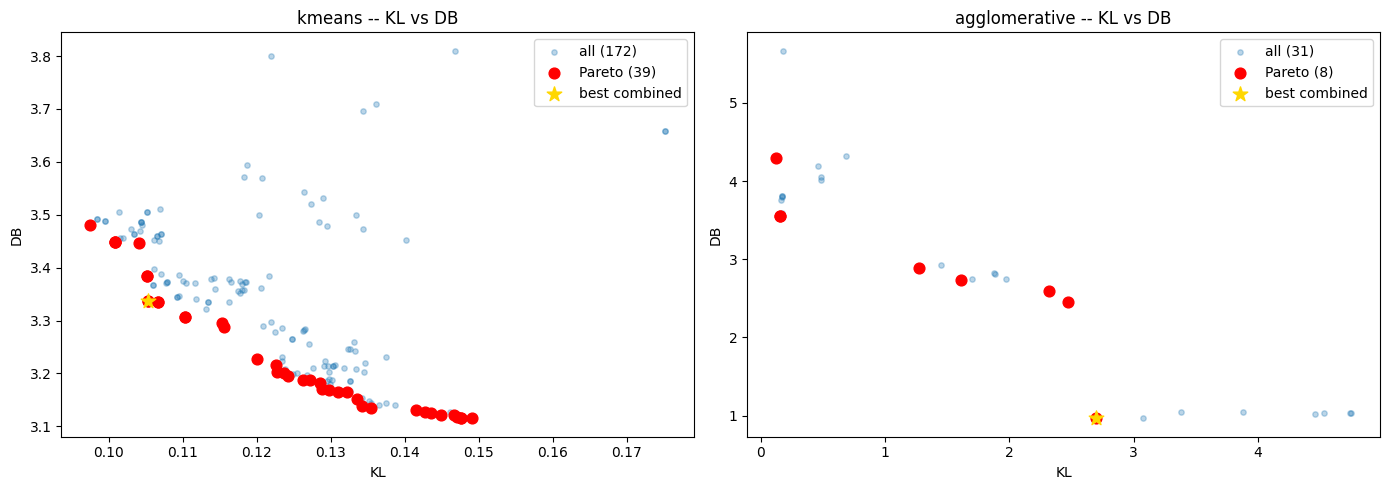

,method,config,cfg,kl_divergence,davies_bouldin,n_clusters,kl_norm,db_norm,combined_score,eps,min_samples,n_levels,fine_k,coarse_k,n_resamples,fine_ss,coarse_ss,mid_k,mid_ss
0,agglomerative,"{'n_clusters': 7, 'linkage': 'ward'}","{'method': 'agglomerative', 'n_clusters': 7, '...",0.124263,4.295594,7.0,NaN,0.000000,0.708452,0.354226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agglomerative,"{'n_clusters': 199, 'linkage': 'ward'}","{'method': 'agglomerative', 'n_clusters': 199,...",0.155353,3.554733,199.0,NaN,0.006720,0.550854,0.278787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,agglomerative,"{'n_clusters': 193, 'linkage': 'ward'}","{'method': 'agglomerative', 'n_clusters': 193,...",0.158764,3.549643,193.0,NaN,0.007457,0.549772,0.278614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,agglomerative,"{'n_clusters': 17, 'linkage': 'average'}","{'method': 'agglomerative', 'n_clusters': 17, ...",1.273248,2.893184,17.0,NaN,0.248350,0.410128,0.329239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,agglomerative,"{'n_clusters': 33, 'linkage': 'average'}","{'method': 'agglomerative', 'n_clusters': 33, ...",1.610293,2.728552,33.0,NaN,0.321201,0.375107,0.348154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,agglomerative,"{'n_clusters': 147, 'linkage': 'average'}","{'method': 'agglomerative', 'n_clusters': 147,...",2.321656,2.594368,147.0,NaN,0.474960,0.346563,0.410761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,agglomerative,"{'n_clusters': 195, 'linkage': 'average'}","{'method': 'agglomerative', 'n_clusters': 195,...",2.474434,2.450492,195.0,NaN,0.507982,0.315958,0.411970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,agglomerative,"{'n_clusters': 15, 'linkage': 'single'}","{'method': 'agglomerative', 'n_clusters': 15, ...",2.700505,0.965187,15.0,NaN,0.556847,0.000000,0.278423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,kmeans,{'n_clusters': 123},"{'method': 'kmeans', 'n_clusters': 123}",0.097462,3.480128,123.0,0.000000,0.525167,0.262584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,kmeans,{'n_clusters': 133},"{'method': 'kmeans', 'n_clusters': 133}",0.100796,3.448107,133.0,0.042893,0.479101,0.260997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
import ast

def ensure_cfg(row):
    """Zwraca cfg jako dict, niezaleznie czy pochodzi z optuna czy CSV."""
    cfg = row.get("cfg") or row.get("config")
    if isinstance(cfg, str):
        cfg = ast.literal_eval(cfg)
    if "method" not in cfg:
        cfg = cfg_from_trial(row["method"], cfg)
    return cfg


def pareto_front(df, col_a="kl_divergence", col_b="davies_bouldin"):
    """Zwraca maske wierszy na froncie Pareto (minimalizacja obu)."""
    vals = df[[col_a, col_b]].values
    is_pareto = np.ones(len(vals), dtype=bool)
    for i in range(len(vals)):
        if not is_pareto[i]:
            continue
        is_pareto[i] = not np.any(
            np.all(vals[:] <= vals[i], axis=1) & np.any(vals[:] < vals[i], axis=1)
        )
    return is_pareto


_have_studies = "studies" in dir() and isinstance(studies, dict) and len(studies) > 0

methods_in_df = df_ranked["method"].unique()
n_methods = len(methods_in_df)

# Pareto front per method -- dostepny po uzyciu niezaleznie od branchа
df_pareto = pd.concat([
    grp[pareto_front(grp)]
    for _, grp in df_ranked.groupby("method")
], ignore_index=True)

if _have_studies:
    fig, axes = plt.subplots(n_methods, 2, figsize=(14, 5 * n_methods))
    if n_methods == 1:
        axes = axes[np.newaxis, :]

    for row_i, method in enumerate(methods_in_df):
        study = studies[method]
        all_completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        pareto_trials = study.best_trials
        best_row = df_ranked[df_ranked["method"] == method].iloc[0]
        pareto_grp = df_pareto[df_pareto["method"] == method]

        axes[row_i, 0].scatter(
            [t.values[0] for t in all_completed],
            [t.values[1] for t in all_completed],
            s=15, alpha=0.3, label="all",
        )
        axes[row_i, 0].scatter(
            pareto_grp["kl_divergence"], pareto_grp["davies_bouldin"],
            s=60, color="red", zorder=5, label=f"Pareto ({len(pareto_grp)})",
        )
        axes[row_i, 0].scatter(
            best_row["kl_divergence"], best_row["davies_bouldin"],
            s=120, color="gold", marker="*", zorder=6, label="best combined",
        )
        axes[row_i, 0].set_xlabel("KL")
        axes[row_i, 0].set_ylabel("DB")
        axes[row_i, 0].set_title(f"{method} -- Pareto ({len(all_completed)} trials)")
        axes[row_i, 0].legend()

        importances = optuna.importance.get_param_importances(
            study, target=lambda t: t.values[0] + t.values[1],
        )
        axes[row_i, 1].barh(list(importances.keys()), list(importances.values()), color="steelblue")
        axes[row_i, 1].set_title(f"{method} -- param importance")

else:
    fig, axes = plt.subplots(1, n_methods, figsize=(7 * n_methods, 5), squeeze=False)

    for col_i, method in enumerate(methods_in_df):
        ax = axes[0, col_i]
        grp = df_ranked[df_ranked["method"] == method]
        best_row = grp.iloc[0]
        pareto_grp = df_pareto[df_pareto["method"] == method]

        ax.scatter(
            grp["kl_divergence"], grp["davies_bouldin"],
            s=15, alpha=0.3, label=f"all ({len(grp)})",
        )
        ax.scatter(
            pareto_grp["kl_divergence"], pareto_grp["davies_bouldin"],
            s=60, color="red", zorder=5, label=f"Pareto ({len(pareto_grp)})",
        )
        ax.scatter(
            best_row["kl_divergence"], best_row["davies_bouldin"],
            s=120, color="gold", marker="*", zorder=6, label="best combined",
        )
        ax.set_xlabel("KL")
        ax.set_ylabel("DB")
        ax.set_title(f"{method} -- KL vs DB")
        ax.legend()

plt.tight_layout()
plt.show()
df_pareto = df_pareto.sort_values(["method", "kl_divergence"]).reset_index(drop=True)
df_pareto

In [14]:
# k 21, 12
# agl 1, 3

Cluster size histograms

  0%|          | 0/4 [00:00<?, ?it/s]

1


 25%|██▌       | 1/4 [00:27<01:22, 27.40s/it]

2
1


 50%|█████     | 2/4 [00:40<00:37, 18.97s/it]

2
1


 75%|███████▌  | 3/4 [02:26<00:58, 58.87s/it]

2
1


100%|██████████| 4/4 [03:46<00:00, 56.70s/it]

2


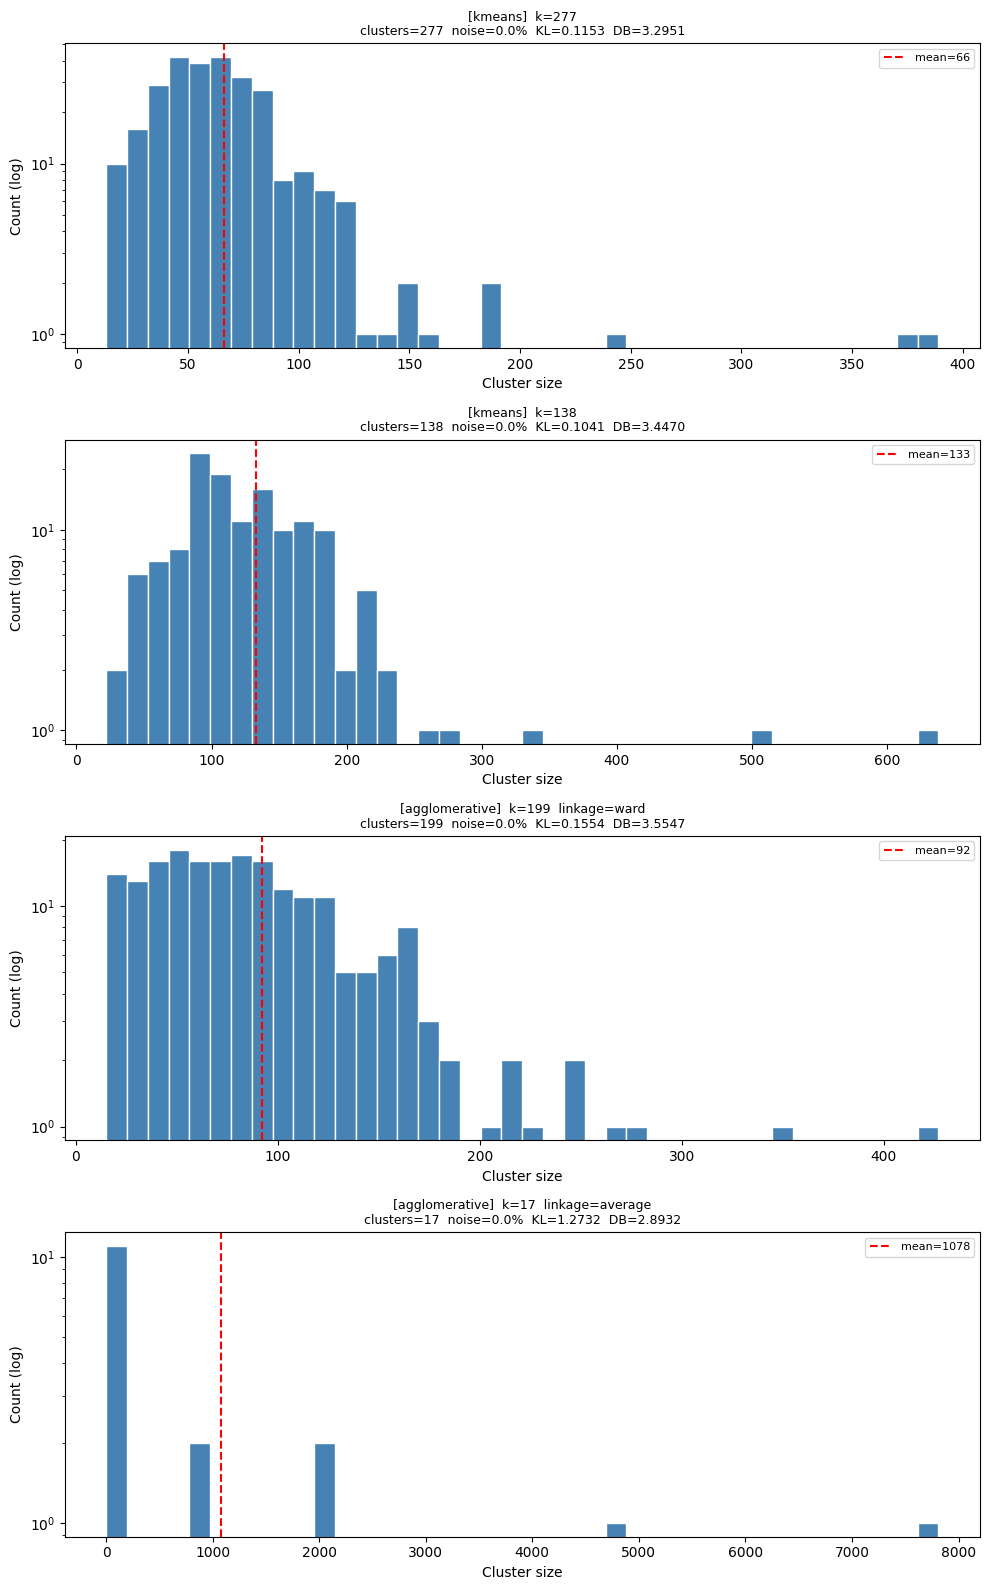

In [15]:
# Wybierz wiersze do wykresu
SELECTED = [21, 12, 1, 3]

labels_list = []
rows_to_plot = [dict(df_pareto.iloc[i]) for i in SELECTED]

# Wykresy
fig, axes = plt.subplots(len(rows_to_plot), 1, figsize=(10, 4 * len(rows_to_plot)))
if len(rows_to_plot) == 1:
    axes = [axes]

for ax, row in tqdm(zip(axes, rows_to_plot), total = len(axes)):
    cfg = ensure_cfg(row)
    set_seed(SEED)
    print(1)
    labels, _ = run_clustering(cfg, embeddings, embeddings_np)
    print(2)
    valid_labels = labels[labels >= 0]
    labels_list.append(valid_labels)
    sizes = np.bincount(valid_labels)
    ax.hist(sizes, bins=40, color="steelblue", edgecolor="white")
    ax.set_yscale("log")
    ax.axvline(sizes.mean(), color="red", linestyle="--", label=f"mean={sizes.mean():.0f}")

    method = row["method"]
    if method == "hierarchical":
        param_str = f"nc={cfg['n_clusters']}  ss={cfg['sample_sizes']}  nr={cfg.get('n_resamples','?')}"
    elif method == "kmeans":
        param_str = f"k={cfg['n_clusters']}"
    elif method == "dbscan":
        param_str = f"eps={cfg['eps']:.2f}  ms={cfg['min_samples']}"
    elif method == "agglomerative":
        param_str = f"k={cfg['n_clusters']}  linkage={cfg.get('linkage','ward')}"
    elif method == "hdbscan":
        param_str = f"mcs={cfg['min_cluster_size']}  ms={cfg.get('min_samples', 5)}"
    else:
        param_str = str(cfg)

    ax.set_title(
        f"[{method}]  {param_str}\n"
        f"clusters={len(sizes)}  noise={noise_fraction(labels):.1%}  "
        f"KL={row['kl_divergence']:.4f}  DB={row['davies_bouldin']:.4f}",
        fontsize=9,
    )
    ax.set_xlabel("Cluster size")
    ax.set_ylabel("Count (log)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## UMAP visualization — best config per method

In [25]:
true_labels = np.array(skewed_ds.targets)
SYNSET_NAMES = skewed_ds.classes

print("Fitting UMAP (shared projection)...")
reducer = umap.UMAP(n_components=2, random_state=SEED, n_jobs=1, verbose=False)
emb_2d = reducer.fit_transform(embeddings_np)
print("UMAP done.")


Fitting UMAP (shared projection)...
UMAP done.


In [26]:
skewed_ds

Dataset ImageFolder
    Number of datapoints: 18330
    Root location: data\places365_10_classes\129\alpha_1\train
    StandardTransform
Transform: <__main__.DinoTransform object at 0x000002398D6D7BE0>

C:\Users\Kacper\AppData\Local\Temp\ipykernel_20744\2551383982.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  class_cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


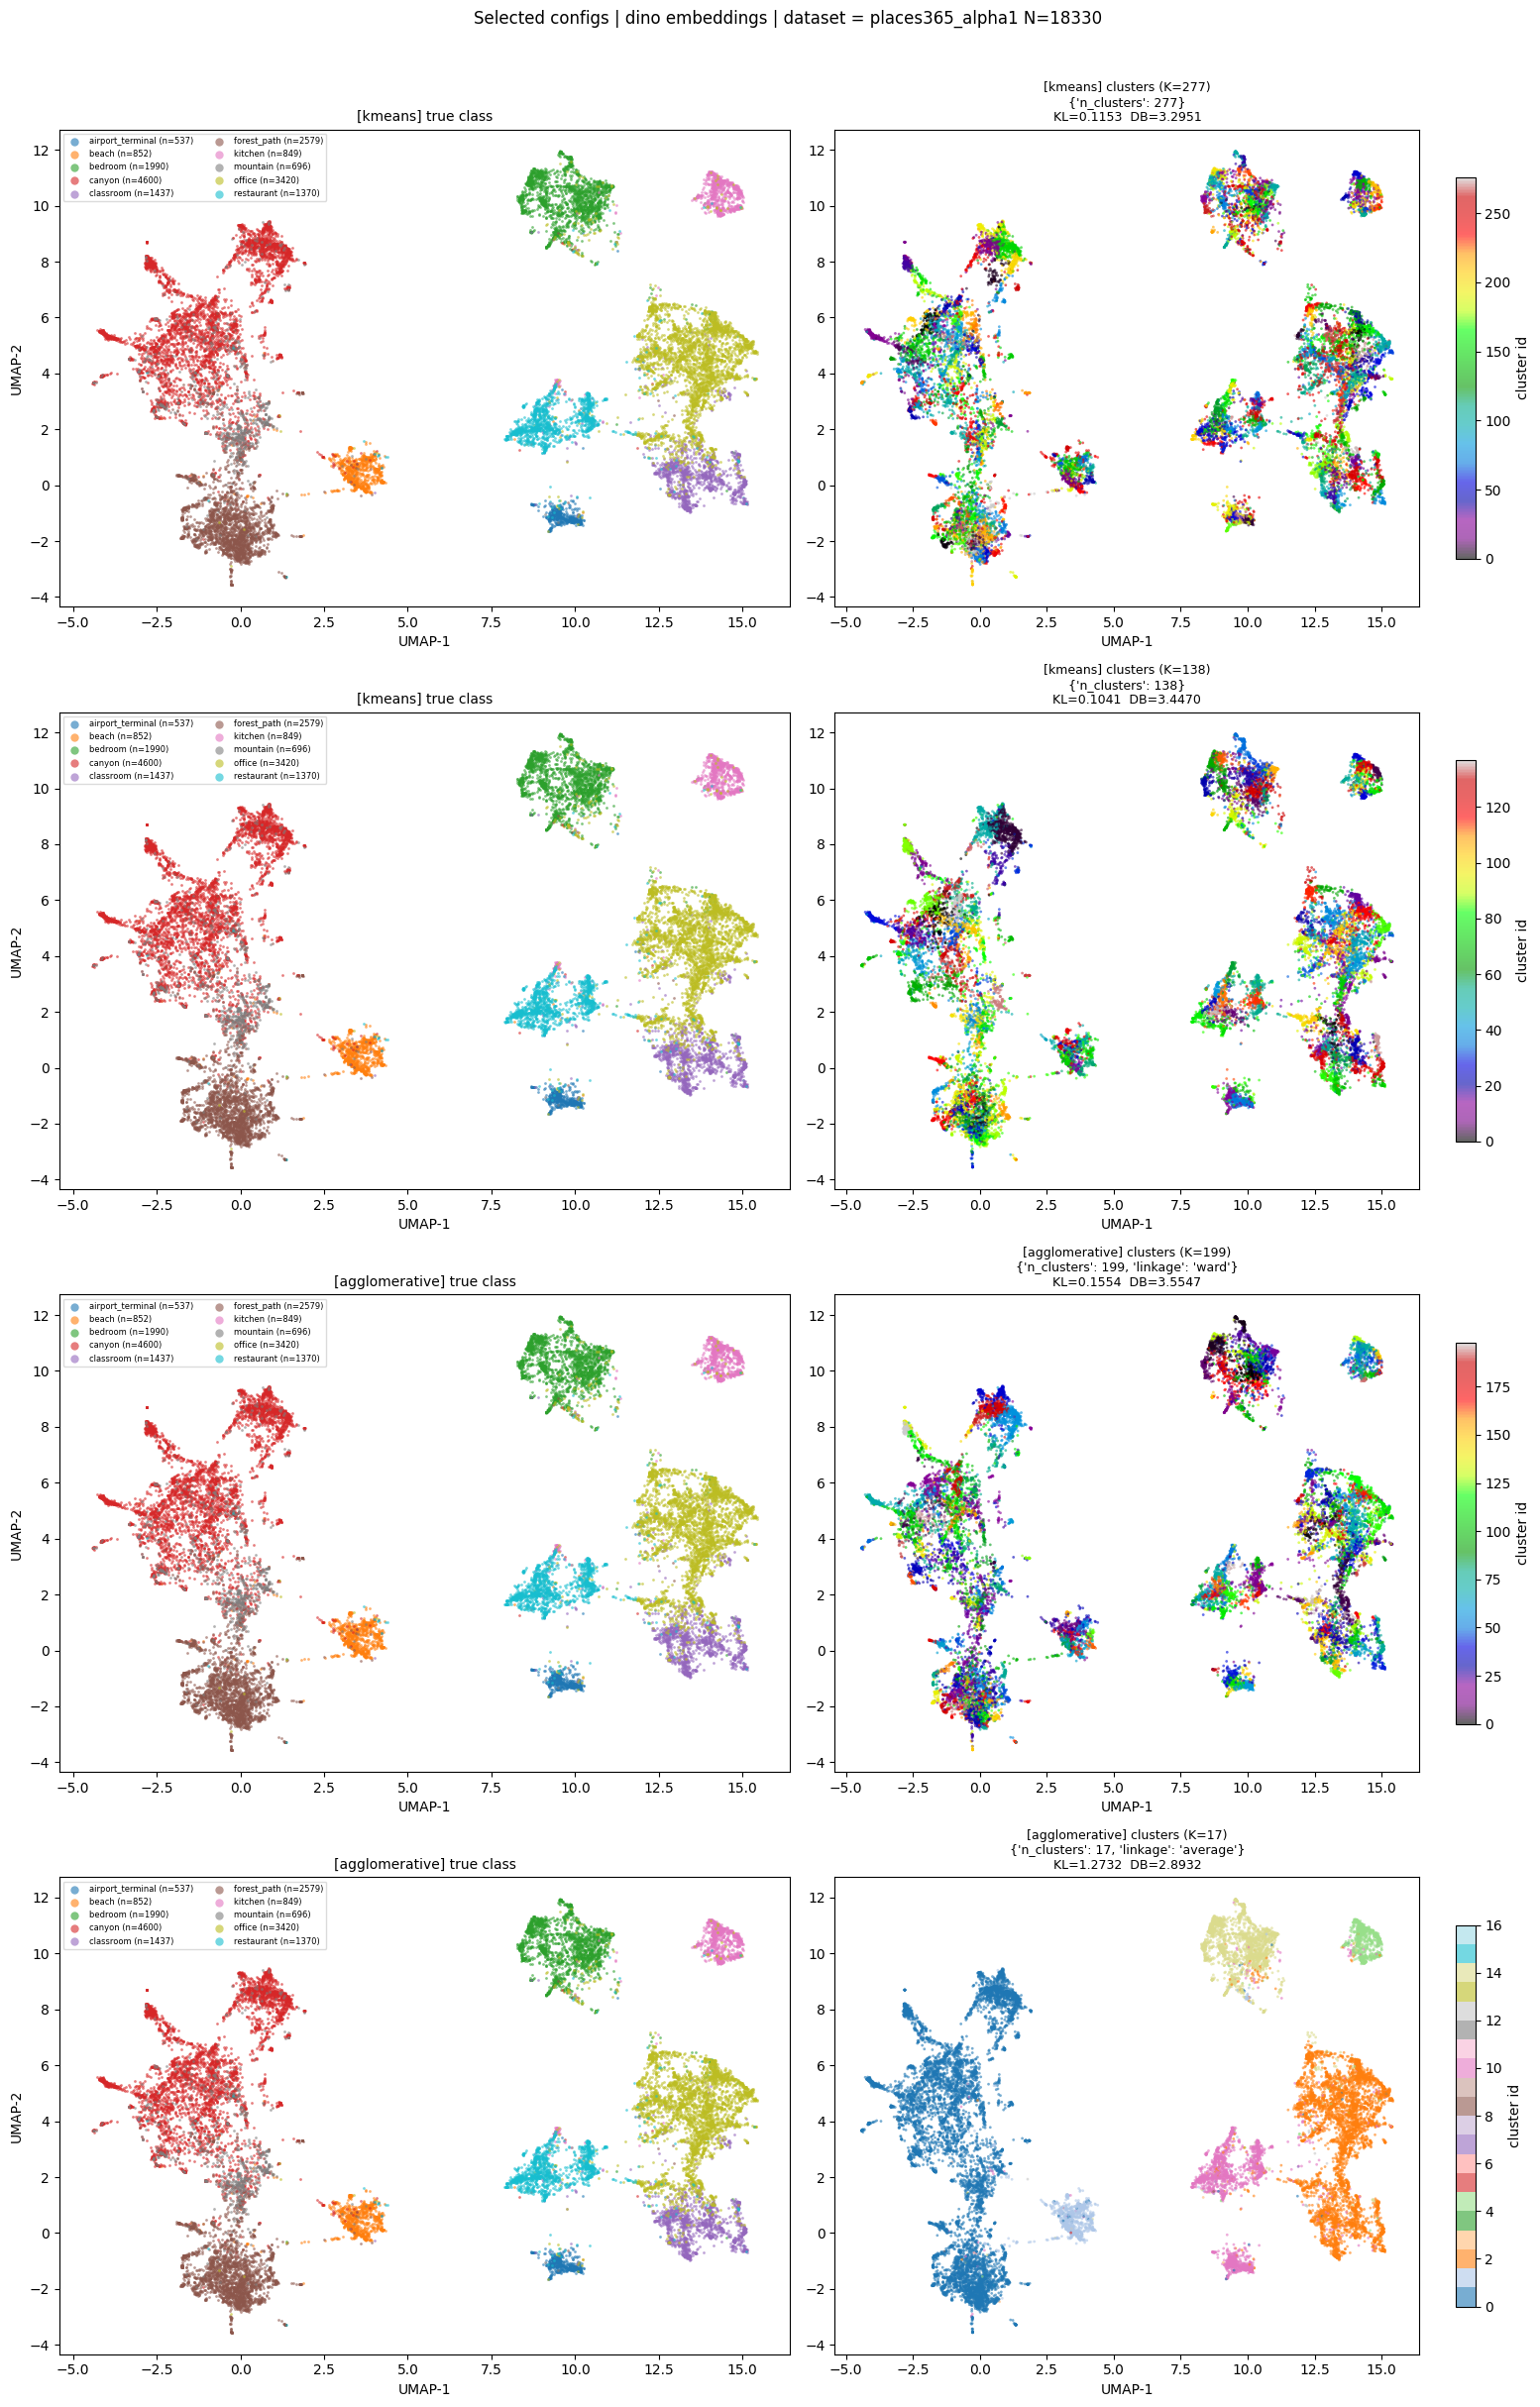

In [28]:
n_rows = len(rows_to_plot)
class_cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 6 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_i, row in enumerate(rows_to_plot):
    method = row["method"]
    labels = labels_list[row_i]
    n_clusters_plot = int(labels.max()) + 1

    ax_l, ax_r = axes[row_i, 0], axes[row_i, 1]

    for cls_id in range(NUM_CLASSES):
        mask = true_labels == cls_id
        ax_l.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            c=[class_cmap(cls_id)], s=4, alpha=0.6, linewidths=0,
            label=f"{SYNSET_NAMES[cls_id]} (n={mask.sum()})",
        )
    ax_l.set_title(f"[{method}] true class", fontsize=10)
    ax_l.set_xlabel("UMAP-1")
    ax_l.set_ylabel("UMAP-2")
    ax_l.legend(markerscale=3, fontsize=6, ncol=2, framealpha=0.7)

    noise_mask = labels == -1
    valid_labels = labels[~noise_mask]

    if noise_mask.any():
        ax_r.scatter(
            emb_2d[noise_mask, 0], emb_2d[noise_mask, 1],
            c="lightgray", s=3, alpha=0.4, linewidths=0,
            label=f"noise (n={noise_mask.sum()})",
        )

    # skala dopasowana do faktycznej liczby klastrow
    n_unique = len(np.unique(valid_labels))
    cmap_name = "tab10" if n_unique <= 10 else "tab20" if n_unique <= 20 else "nipy_spectral"
    sc = ax_r.scatter(
        emb_2d[~noise_mask, 0], emb_2d[~noise_mask, 1],
        c=valid_labels, cmap=cmap_name, s=4, alpha=0.6, linewidths=0,
        vmin=valid_labels.min(), vmax=valid_labels.max(),
    )

    config_raw = row.get("config", str(ensure_cfg(row)))
    if isinstance(config_raw, str) and "|" in config_raw:
        param_str = config_raw.split("|")[-1].strip()
    else:
        param_str = str(config_raw)[:80]

    ax_r.set_title(
        f"[{method}] clusters (K={n_clusters_plot})\n{param_str}\n"
        f"KL={row['kl_divergence']:.4f}  DB={row['davies_bouldin']:.4f}",
        fontsize=9,
    )
    ax_r.set_xlabel("UMAP-1")
    if noise_mask.any():
        ax_r.legend(markerscale=3, fontsize=7, framealpha=0.7)
    plt.colorbar(sc, ax=ax_r, label="cluster id", shrink=0.8)

fig.suptitle(
    f"Selected configs | {EMBEDDINGS} embeddings | dataset = {DATASET} N={len(skewed_ds)}",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig("umap_best_per_method.png", dpi=150, bbox_inches="tight")
plt.show()